#### Titanic Survival Prediction

In [267]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

### Data Preprocessing

In [268]:
df = pd.read_csv("..\\data\\raw\\train.csv")

In [269]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [270]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [271]:
df['Age'].isnull().sum()

np.int64(177)

<Axes: xlabel='Age', ylabel='Count'>

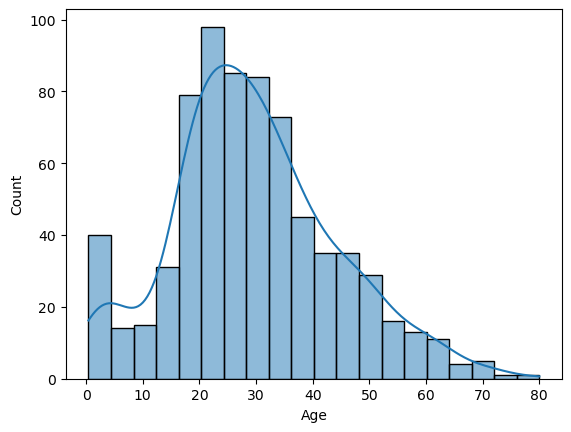

In [272]:
sns.histplot(df['Age'], kde=True)

In [273]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [274]:
df['Age'].isna().sum()

np.int64(0)

<Axes: xlabel='Age', ylabel='Count'>

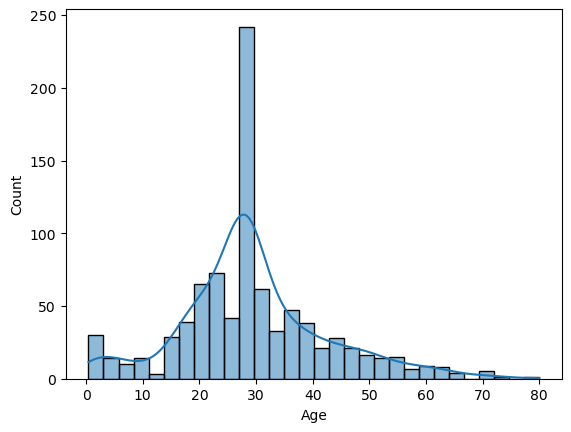

In [275]:
sns.histplot(df['Age'], kde=True)

In [276]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [277]:
# Calculate the percentage of missing values in the 'Cabin' column

(df['Cabin'].isna().sum() / len(df)) * 100

np.float64(77.10437710437711)

In [278]:
# Dropping the cabin column as it has more than 77% missing values

df = df.drop('Cabin', axis=1)

In [279]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [280]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [281]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [282]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

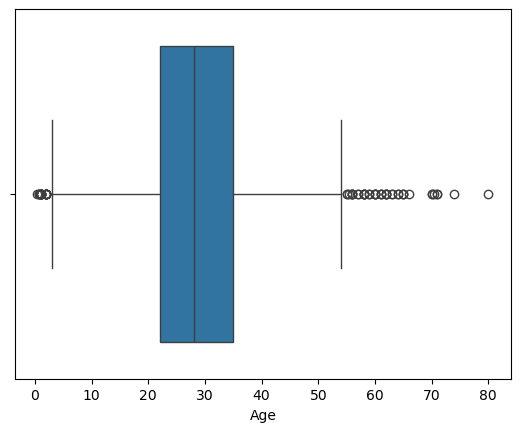

In [283]:
sns.boxplot(x=df['Age'])
plt.show()

In [284]:
z_scores = np.abs(stats.zscore(df['Age']))

In [285]:
(z_scores > 3).sum()

np.int64(7)

In [286]:
outliers = df['Age'][z_scores > 3]

In [287]:
outliers

96     71.0
116    70.5
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64

In [288]:
# I did not remove the outliers as they are not extreme and they are not affecting the model performance. 
# I will keep them in the dataset.

In [289]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [290]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [291]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [292]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

<Axes: xlabel='Fare', ylabel='Count'>

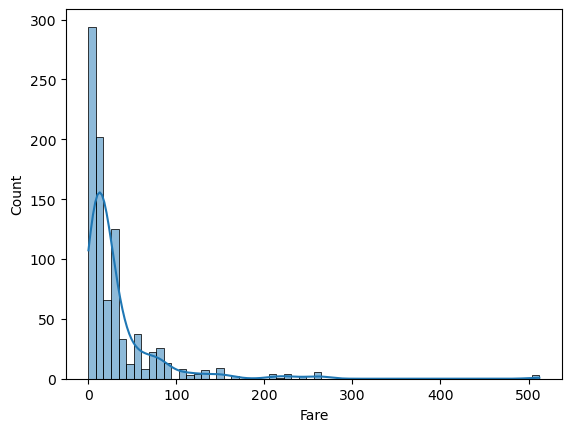

In [293]:
sns.histplot(df['Fare'], kde=True)

In [294]:
(df['Fare'] == 0).sum()

np.int64(15)

In [295]:

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [296]:
# Extracting the title from the name column and creating a new column for it

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [297]:
df.drop('Name', axis=1, inplace=True)

In [298]:
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [299]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Mr


In [300]:
# Encoding the categorical variables using label encoding

le_sex = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])

In [301]:
df['Sex'].unique()

array([1, 0])

In [302]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,0,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,1,35.0,0,0,373450,8.0500,S,Mr


In [303]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [304]:
# Encoding the 'Embarked' column using one-hot encoding

ohe = OneHotEncoder(sparse_output=False)

In [305]:
encoded_embarked = ohe.fit_transform(df[['Embarked']])

In [306]:
encoded_df = pd.DataFrame(encoded_embarked, columns=ohe.get_feature_names_out(['Embarked']))

In [307]:
# DROPPED ORIGINAL AND EMBEDDED ONE HOT EMBARKED COLUMNS
df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)

In [308]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,Mr,0.0,0.0,1.0
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,Mrs,1.0,0.0,0.0
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,Miss,0.0,0.0,1.0
3,4,1,1,0,35.0,1,0,113803,53.1000,Mrs,0.0,0.0,1.0
4,5,0,3,1,35.0,0,0,373450,8.0500,Mr,0.0,0.0,1.0


In [309]:
df['Pclass'].unique()

array([3, 1, 2])

In [310]:
# I will not discretize the age column as it is not necessary for this dataset 
# and it may lead to loss of information.

# age_discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal')
# df['Age'] = age_discretizer.fit_transform(df[['Age']])

In [311]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,Mr,0.0,0.0,1.0
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,Mrs,1.0,0.0,0.0
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,Miss,0.0,0.0,1.0
3,4,1,1,0,35.0,1,0,113803,53.1000,Mrs,0.0,0.0,1.0
4,5,0,3,1,35.0,0,0,373450,8.0500,Mr,0.0,0.0,1.0


In [312]:
# Applying log transformation to the 'Fare' column to reduce the skewness

df['Fare'] = np.log1p(df['Fare'])

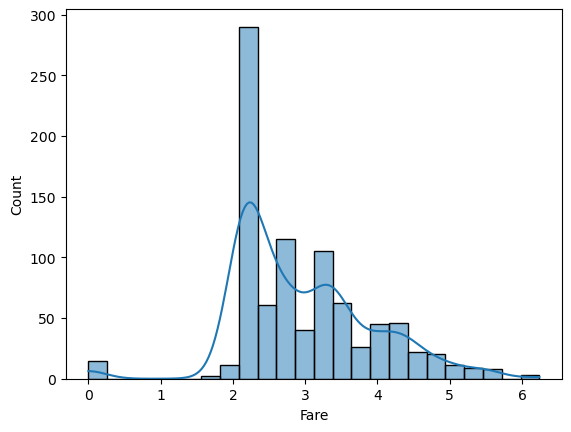

In [313]:
sns.histplot(df['Fare'], kde=True)
plt.show()

In [314]:
# Scaling the numerical features using standard scaler

scaler = StandardScaler()

In [315]:
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

In [316]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,-0.565736,1,0,A/5 21171,-0.879741,Mr,0.0,0.0,1.0
1,2,1,1,0,0.663861,1,0,PC 17599,1.361220,Mrs,1.0,0.0,0.0
2,3,1,3,0,-0.258337,0,0,STON/O2. 3101282,-0.798540,Miss,0.0,0.0,1.0
3,4,1,1,0,0.433312,1,0,113803,1.062038,Mrs,0.0,0.0,1.0
4,5,0,3,1,0.433312,0,0,373450,-0.784179,Mr,0.0,0.0,1.0


In [317]:
# After standard scaling, the values of 'Fare' column are now in the range of -3 to 3.
# Values greater than 3 are considered as outliers.

df[df['Fare'] > 3].value_counts().sum()

np.int64(3)

In [318]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,-0.565736,1,0,A/5 21171,-0.879741,Mr,0.0,0.0,1.0
1,2,1,1,0,0.663861,1,0,PC 17599,1.361220,Mrs,1.0,0.0,0.0
2,3,1,3,0,-0.258337,0,0,STON/O2. 3101282,-0.798540,Miss,0.0,0.0,1.0
3,4,1,1,0,0.433312,1,0,113803,1.062038,Mrs,0.0,0.0,1.0
4,5,0,3,1,0.433312,0,0,373450,-0.784179,Mr,0.0,0.0,1.0


In [319]:
print(df['Ticket'].dtype)

object


In [320]:
df = df.drop(columns=['Ticket'])

In [321]:
# Creating a new feature 'FamilySize' by combining 'SibSp' and 'Parch' columns

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [322]:
df = df.drop(columns=['SibSp'])
df = df.drop(columns=['Parch'])

In [323]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Title,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,1,0,3,1,-0.565736,-0.879741,Mr,0.0,0.0,1.0,2
1,2,1,1,0,0.663861,1.361220,Mrs,1.0,0.0,0.0,2
2,3,1,3,0,-0.258337,-0.798540,Miss,0.0,0.0,1.0,1
3,4,1,1,0,0.433312,1.062038,Mrs,0.0,0.0,1.0,2
4,5,0,3,1,0.433312,-0.784179,Mr,0.0,0.0,1.0,1


In [324]:
df['Title'].nunique()

17

In [325]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Rev': 'Rev'
}

# Map titles, everything else becomes 'Other'
df['Title'] = df['Title'].map(lambda x: title_mapping.get(x, 'Other'))

In [326]:
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Other', 'Rev'], dtype=object)

In [327]:
# Encoding the 'Title' column using label encoding

le_title = LabelEncoder()
df['Title'] = le_title.fit_transform(df['Title'])

In [328]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Title,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,1,0,3,1,-0.565736,-0.879741,1,0.0,0.0,1.0,2
1,2,1,1,0,0.663861,1.361220,2,1.0,0.0,0.0,2
2,3,1,3,0,-0.258337,-0.798540,0,0.0,0.0,1.0,1
3,4,1,1,0,0.433312,1.062038,2,0.0,0.0,1.0,2
4,5,0,3,1,0.433312,-0.784179,1,0.0,0.0,1.0,1


In [329]:
# Data is now preprocessed and ready for model training.

In [330]:
df.to_csv(r"../data/processed/train_processed.csv", index=False)

### Model Training and Evaluation

In [331]:
X = df.drop(columns='Survived')
y = df['Survived']

In [332]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# This is just to check the performance of the model on the validation set.

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

accuracy_score(y_val, y_pred)

0.7877094972067039

In [333]:
# Now that we have checked the performance of the model on the validation set, 
# we can fit the model on the entire dataset.

model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [334]:
df = pd.read_csv("../data/raw/test.csv")

In [335]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [336]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [337]:
df = df.drop('Cabin', axis=1)

In [338]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [339]:
z_scores = np.abs(stats.zscore(df['Age']))
outliers = df['Age'][z_scores > 3]

In [340]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)

In [341]:
df.drop('Name', axis=1, inplace=True)

In [342]:
df['Sex'] = le_sex.transform(df['Sex'])

In [343]:
encoded_embarked = ohe.transform(df[['Embarked']])
encoded_df = pd.DataFrame(encoded_embarked, columns=ohe.get_feature_names_out(['Embarked']))

In [344]:
# DROPPED ORIGINAL AND EMBEDDED ONE HOT EMBARKED COLUMNS
df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)

In [345]:
df['Fare'] = np.log1p(df['Fare'])

In [346]:
df[['Age', 'Fare']] = scaler.transform(df[['Age', 'Fare']])

In [347]:
df = df.drop(columns=['Ticket'])

In [348]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

df = df.drop(columns=['SibSp'])
df = df.drop(columns=['Parch'])

In [349]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Rev': 'Rev'
}

# Map titles, everything else becomes 'Other'
df['Title'] = df['Title'].map(lambda x: title_mapping.get(x, 'Other'))

In [350]:
df['Title'] = le_title.transform(df['Title'])

In [351]:
df.head()

,PassengerId,Pclass,Sex,Age,Fare,Title,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,892,3,1,0.394887,-0.809683,1,0.0,1.0,0.0,1
1,893,3,0,1.355510,-0.911513,2,0.0,0.0,1.0,2
2,894,2,1,2.508257,-0.612461,1,0.0,1.0,0.0,1
3,895,3,1,-0.181487,-0.716562,1,0.0,0.0,1.0,1
4,896,3,0,-0.565736,-0.387631,2,0.0,0.0,1.0,3


In [352]:
predictions = model.predict(df)

In [353]:
submission = pd.DataFrame({
    "PassengerId": df["PassengerId"],
    "Survived": predictions
})

submission.to_csv(r"../data/submission.csv", index=False)